In [21]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt

# Read-only connection for EDA
con = duckdb.connect("developer_project.duckdb", read_only=True)

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)

print("Tables in database:")
print(con.execute("SHOW TABLES").fetchdf())

Tables in database:
                                      name
0                          activity_capped
1                           activity_clean
2                           activity_final
3                             activity_raw
4                          activity_sample
5                    activity_score_bounds
6             activity_score_mapping_clean
7               activity_score_mapping_raw
8                          activity_scored
9                           activity_stage
10                   activity_standardized
11                  activity_user_features
12                           contact_clean
13  contact_clean_backup_before_supplement
14                           contact_final
15                             contact_raw
16                          contact_sample
17                           contact_stage
18                contact_supplement_clean
19                  contact_supplement_raw
20                  developer_feature_base
21                      sdk_downlo

# What the data looks like

In [22]:
print("\nFinal row count and distinct users:")
print(con.execute("""
SELECT
    COUNT(*) AS row_count,
    COUNT(DISTINCT developer_id) AS distinct_users
FROM developer_feature_base
""").fetchdf())

print("\nDuplicate developer_id check:")
print(con.execute("""
SELECT developer_id, COUNT(*) AS cnt
FROM developer_feature_base
GROUP BY developer_id
HAVING COUNT(*) > 1
LIMIT 20
""").fetchdf())

print("\nMissing developer_id check:")
print(con.execute("""
SELECT
    COUNT(*) AS total_rows,
    SUM(CASE WHEN developer_id IS NULL OR TRIM(developer_id) = '' THEN 1 ELSE 0 END) AS missing_developer_id
FROM developer_feature_base
""").fetchdf())

print("\nJoin coverage:")
print(con.execute("""
SELECT
    COUNT(DISTINCT c.developer_id) AS total_contact_users,
    COUNT(DISTINCT a.developer_id) AS matched_activity_users,
    COUNT(DISTINCT c.developer_id) - COUNT(DISTINCT a.developer_id) AS users_without_activity
FROM contact_final c
LEFT JOIN activity_user_features a
    ON c.developer_id = a.developer_id
""").fetchdf())

print("\nFeature null checks:")
print(con.execute("""
SELECT
    SUM(CASE WHEN total_activities_all_time IS NULL THEN 1 ELSE 0 END) AS null_total_activities,
    SUM(CASE WHEN total_activity_score_all_time IS NULL THEN 1 ELSE 0 END) AS null_total_score,
    SUM(CASE WHEN days_since_last_activity IS NULL THEN 1 ELSE 0 END) AS null_days_since_last_activity
FROM developer_feature_base
""").fetchdf())

print("\nFeature distribution summary:")
print(con.execute("""
SELECT
    MIN(total_activities_all_time) AS min_total_activities,
    MAX(total_activities_all_time) AS max_total_activities,
    AVG(total_activities_all_time) AS avg_total_activities,
    MIN(total_activity_score_all_time) AS min_total_score,
    MAX(total_activity_score_all_time) AS max_total_score,
    AVG(total_activity_score_all_time) AS avg_total_score
FROM developer_feature_base
""").fetchdf())

print("\nRecent activity window checks:")
print(con.execute("""
SELECT
    SUM(CASE WHEN activity_cnt_30d > activity_cnt_90d THEN 1 ELSE 0 END) AS bad_30_gt_90,
    SUM(CASE WHEN activity_cnt_90d > activity_cnt_180d THEN 1 ELSE 0 END) AS bad_90_gt_180,
    SUM(CASE WHEN activity_cnt_180d > activity_cnt_360d THEN 1 ELSE 0 END) AS bad_180_gt_360
FROM developer_feature_base
""").fetchdf())

print("\nScore window checks:")
print(con.execute("""
SELECT
    SUM(CASE WHEN activity_score_30d > activity_score_90d THEN 1 ELSE 0 END) AS bad_score_30_gt_90,
    SUM(CASE WHEN activity_score_90d > activity_score_180d THEN 1 ELSE 0 END) AS bad_score_90_gt_180,
    SUM(CASE WHEN activity_score_180d > activity_score_360d THEN 1 ELSE 0 END) AS bad_score_180_gt_360
FROM developer_feature_base
""").fetchdf())

print("\nPreview final joined dataset:")
print(con.execute("""
SELECT *
FROM developer_feature_base
LIMIT 20
""").fetchdf())




Final row count and distinct users:
   row_count  distinct_users
0    9381490         9381490

Duplicate developer_id check:
Empty DataFrame
Columns: [developer_id, cnt]
Index: []

Missing developer_id check:
   total_rows  missing_developer_id
0     9381490                   0.0

Join coverage:
   total_contact_users  matched_activity_users  users_without_activity
0              9381490                 7654410                 1727080

Feature null checks:
   null_total_activities  null_total_score  null_days_since_last_activity
0                    0.0               0.0                            0.0

Feature distribution summary:
   min_total_activities  max_total_activities  avg_total_activities  \
0                     0               2027375              7.281723   

   min_total_score  max_total_score  avg_total_score  
0              0.0       10015777.0        24.284601  

Recent activity window checks:
   bad_30_gt_90  bad_90_gt_180  bad_180_gt_360
0           0.0            

In [23]:
print("\nQuantiles for total activities:")
print(con.execute("""
SELECT
    QUANTILE_CONT(total_activities_all_time, 0.50) AS p50,
    QUANTILE_CONT(total_activities_all_time, 0.90) AS p90,
    QUANTILE_CONT(total_activities_all_time, 0.99) AS p99,
    QUANTILE_CONT(total_activities_all_time, 0.999) AS p999,
    MAX(total_activities_all_time) AS max_val
FROM developer_feature_base
""").fetchdf())

print("\nQuantiles for total activity score:")
print(con.execute("""
SELECT
    QUANTILE_CONT(total_activity_score_all_time, 0.50) AS p50,
    QUANTILE_CONT(total_activity_score_all_time, 0.90) AS p90,
    QUANTILE_CONT(total_activity_score_all_time, 0.99) AS p99,
    QUANTILE_CONT(total_activity_score_all_time, 0.999) AS p999,
    MAX(total_activity_score_all_time) AS max_val
FROM developer_feature_base
""").fetchdf())

print("\nUsers without activity by source:")
print(con.execute("""
SELECT
    program_application_source,
    COUNT(*) AS users_without_activity
FROM developer_feature_base
WHERE total_activities_all_time = 0
GROUP BY 1
ORDER BY 2 DESC
LIMIT 20
""").fetchdf())

print("\nUsers without activity by country:")
print(con.execute("""
SELECT
    country,
    COUNT(*) AS users_without_activity
FROM developer_feature_base
WHERE total_activities_all_time = 0
GROUP BY 1
ORDER BY 2 DESC
LIMIT 20
""").fetchdf())

print("\nTop 20 most active users:")
print(con.execute("""
SELECT developer_id, total_activities_all_time, total_activity_score_all_time
FROM developer_feature_base
ORDER BY total_activities_all_time DESC, total_activity_score_all_time DESC
LIMIT 20
""").fetchdf())


Quantiles for total activities:
   p50  p90    p99   p999  max_val
0  2.0  7.0  114.0  568.0  2027375

Quantiles for total activity score:
   p50   p90    p99      p999     max_val
0  4.0  36.0  341.0  1540.511  10015777.0

Users without activity by source:
   program_application_source  users_without_activity
0                     unknown                 1264055
1                     devzone                  389421
2               gtc fall 2022                   47572
3             gtc spring 2022                   13584
4                 api_catalog                    9362
5                         gtc                    2489
6                         dli                     486
7                        brev                      74
8                         nod                      21
9                         hwg                      14
10                        ngc                       2

Users without activity by country:
               country  users_without_activity
0         

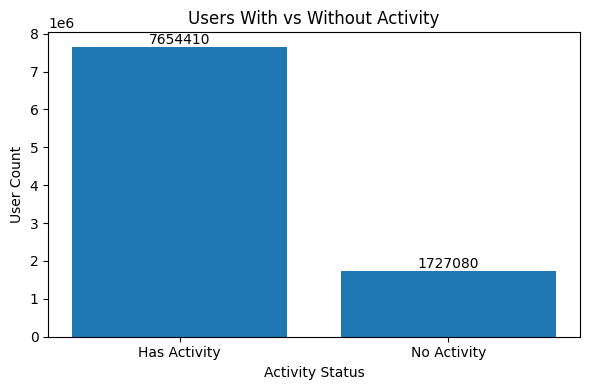

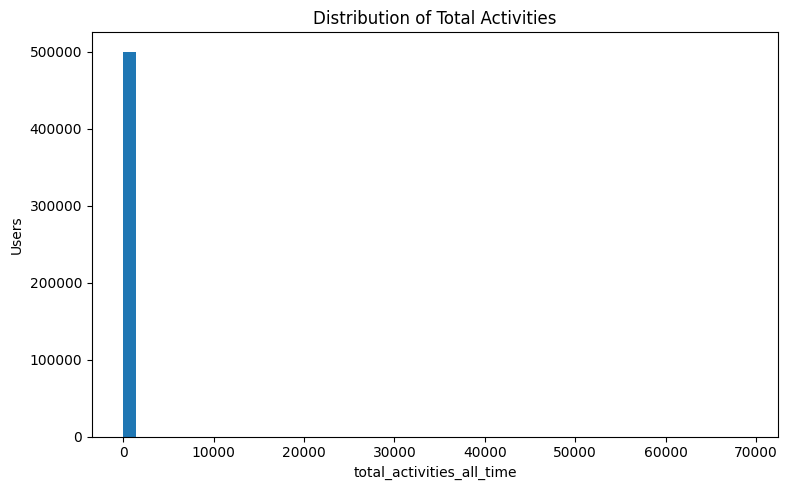

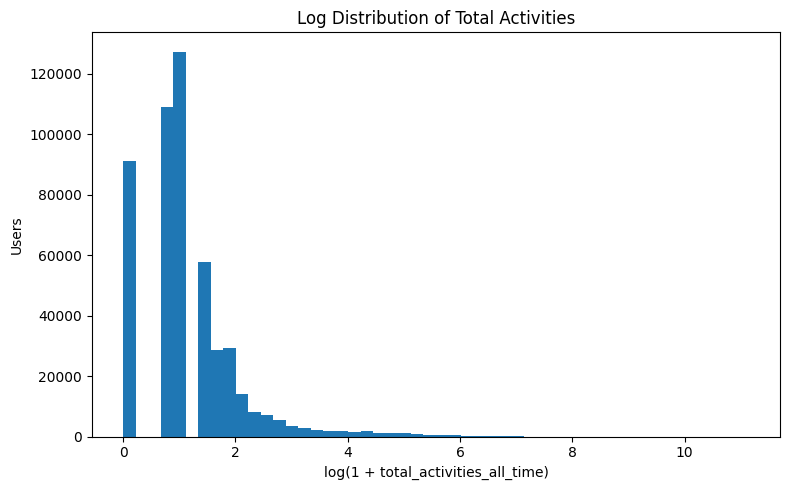

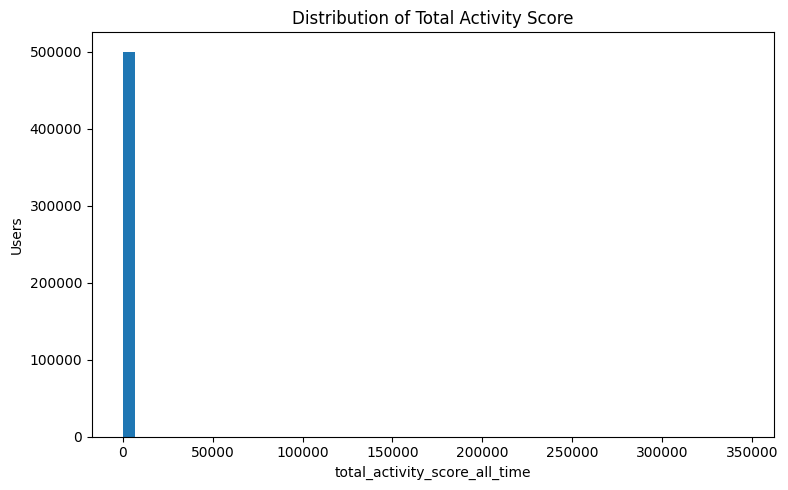

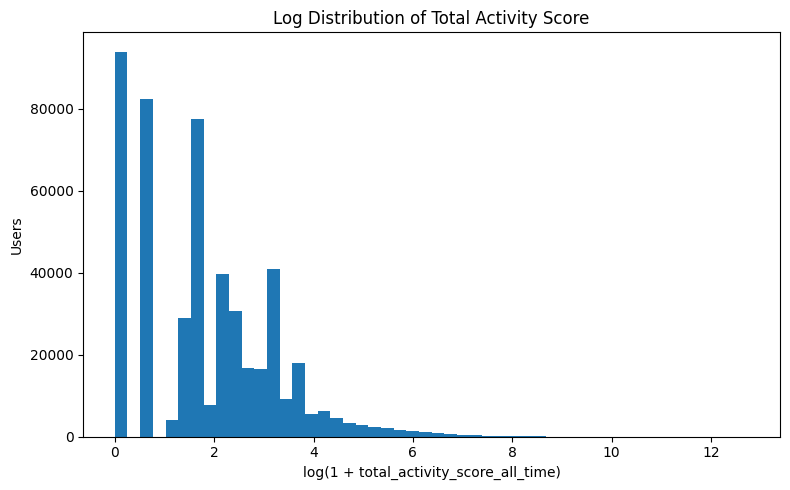

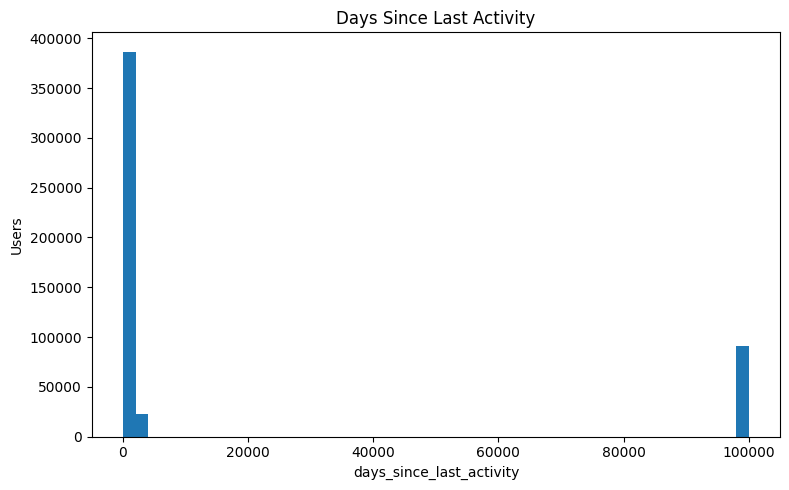

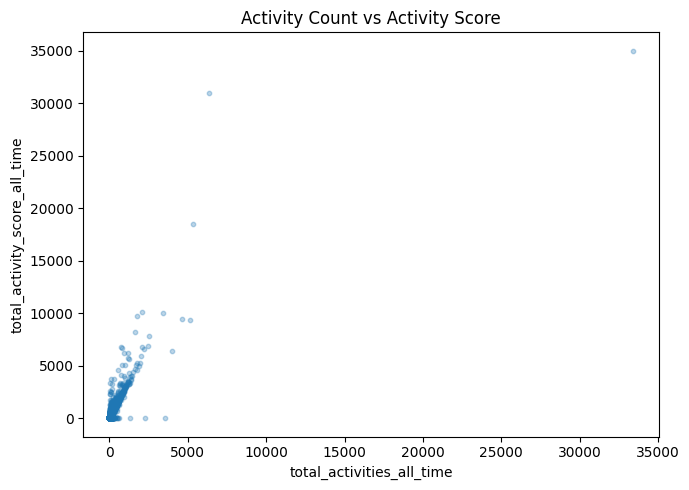

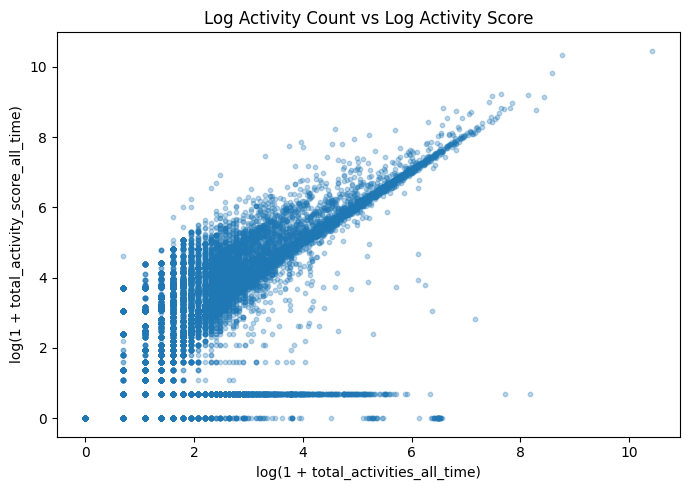

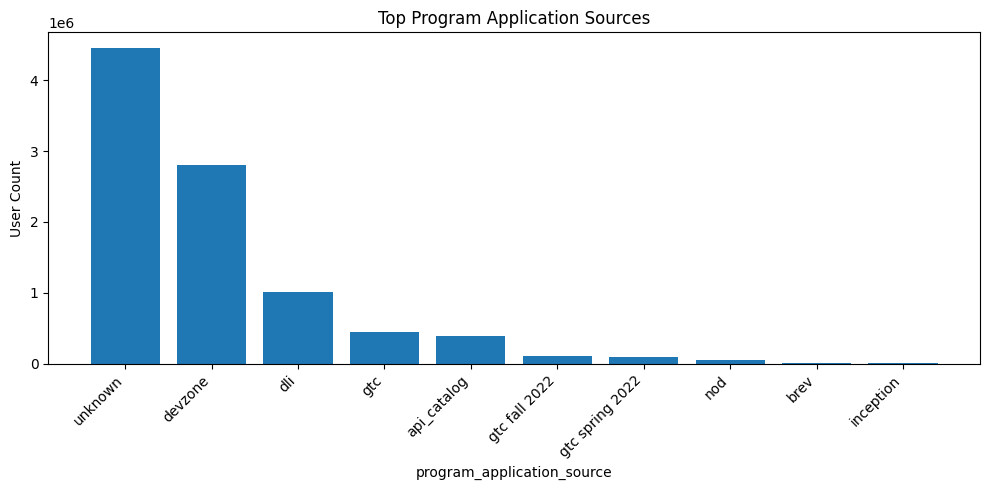

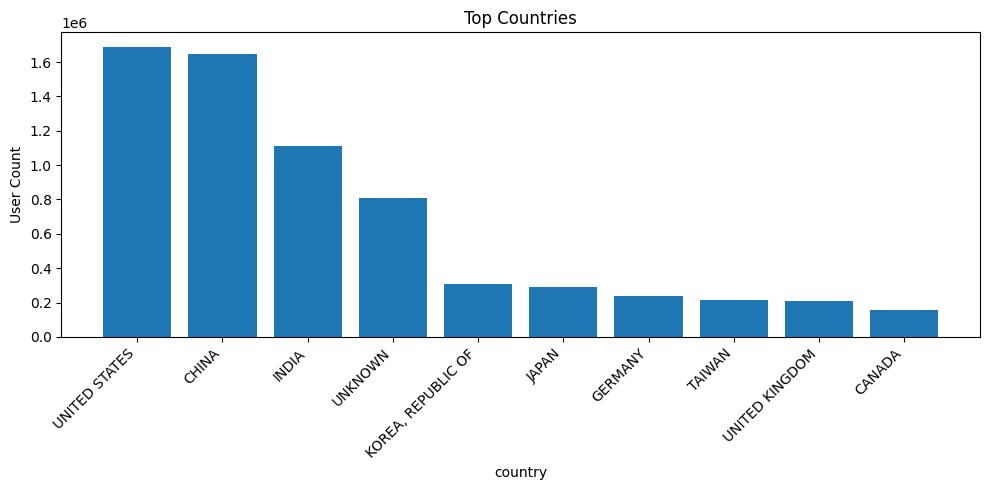

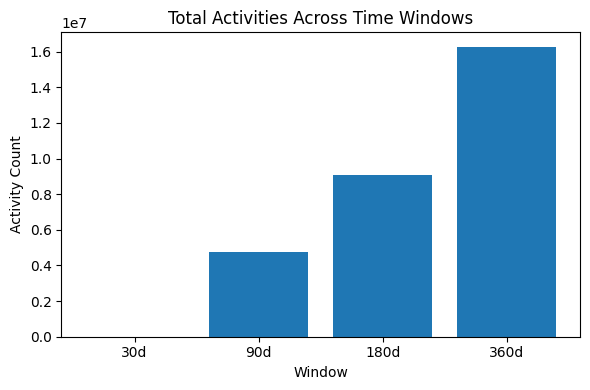

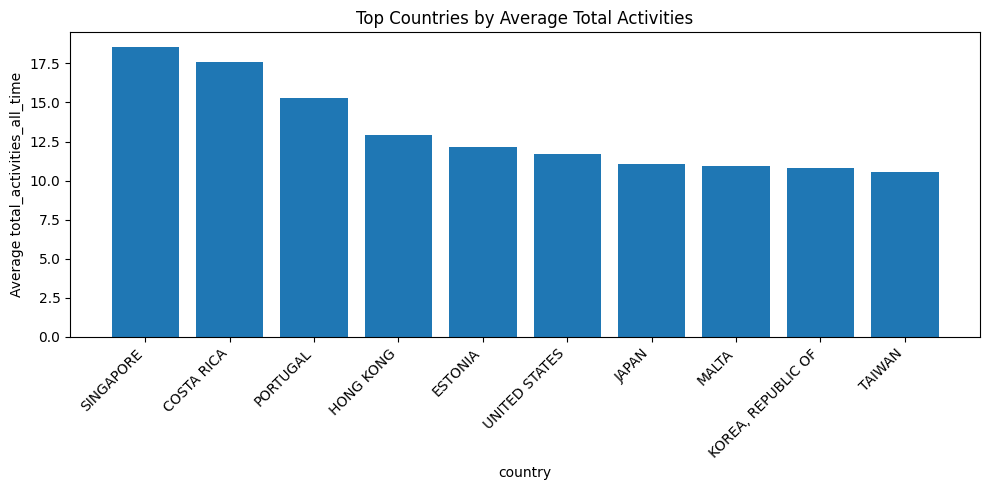

In [24]:

# 3.1 Users with vs without activity
df = con.execute("""
SELECT
    CASE
        WHEN total_activities_all_time = 0 THEN 'No Activity'
        ELSE 'Has Activity'
    END AS activity_status,
    COUNT(*) AS user_count
FROM developer_feature_base
GROUP BY 1
ORDER BY 2 DESC
""").fetchdf()

plt.figure(figsize=(6, 4))

bars = plt.bar(df["activity_status"], df["user_count"])

plt.title("Users With vs Without Activity")
plt.xlabel("Activity Status")
plt.ylabel("User Count")

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height)}",
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()


# 3.2 Distribution of total activities
df = con.execute("""
SELECT total_activities_all_time
FROM developer_feature_base
WHERE total_activities_all_time IS NOT NULL
LIMIT 500000
""").fetchdf()

plt.figure(figsize=(8, 5))
plt.hist(df["total_activities_all_time"], bins=50)
plt.title("Distribution of Total Activities")
plt.xlabel("total_activities_all_time")
plt.ylabel("Users")
plt.tight_layout()
plt.show()


# 3.3 Log distribution of total activities
df = con.execute("""
SELECT LN(1 + total_activities_all_time) AS log_total_activities
FROM developer_feature_base
WHERE total_activities_all_time IS NOT NULL
LIMIT 500000
""").fetchdf()

plt.figure(figsize=(8, 5))
plt.hist(df["log_total_activities"], bins=50)
plt.title("Log Distribution of Total Activities")
plt.xlabel("log(1 + total_activities_all_time)")
plt.ylabel("Users")
plt.tight_layout()
plt.show()


# 3.4 Distribution of total activity score
df = con.execute("""
SELECT total_activity_score_all_time
FROM developer_feature_base
WHERE total_activity_score_all_time IS NOT NULL
LIMIT 500000
""").fetchdf()

plt.figure(figsize=(8, 5))
plt.hist(df["total_activity_score_all_time"], bins=50)
plt.title("Distribution of Total Activity Score")
plt.xlabel("total_activity_score_all_time")
plt.ylabel("Users")
plt.tight_layout()
plt.show()


# 3.5 Log distribution of total activity score
df = con.execute("""
SELECT LN(1 + total_activity_score_all_time) AS log_total_score
FROM developer_feature_base
WHERE total_activity_score_all_time IS NOT NULL
LIMIT 500000
""").fetchdf()

plt.figure(figsize=(8, 5))
plt.hist(df["log_total_score"], bins=50)
plt.title("Log Distribution of Total Activity Score")
plt.xlabel("log(1 + total_activity_score_all_time)")
plt.ylabel("Users")
plt.tight_layout()
plt.show()


# 3.6 Days since last activity
df = con.execute("""
SELECT days_since_last_activity
FROM developer_feature_base
WHERE days_since_last_activity IS NOT NULL
LIMIT 500000
""").fetchdf()

plt.figure(figsize=(8, 5))
plt.hist(df["days_since_last_activity"], bins=50)
plt.title("Days Since Last Activity")
plt.xlabel("days_since_last_activity")
plt.ylabel("Users")
plt.tight_layout()
plt.show()


# 3.7 Activity count vs activity score
df = con.execute("""
SELECT
    total_activities_all_time,
    total_activity_score_all_time
FROM developer_feature_base
WHERE total_activities_all_time > 0
  AND total_activity_score_all_time > 0
LIMIT 100000
""").fetchdf()

plt.figure(figsize=(7, 5))
plt.scatter(
    df["total_activities_all_time"],
    df["total_activity_score_all_time"],
    alpha=0.3,
    s=10
)
plt.title("Activity Count vs Activity Score")
plt.xlabel("total_activities_all_time")
plt.ylabel("total_activity_score_all_time")
plt.tight_layout()
plt.show()


# 3.8 Log activity count vs log activity score
df = con.execute("""
SELECT
    LN(1 + total_activities_all_time) AS log_activities,
    LN(1 + total_activity_score_all_time) AS log_score
FROM developer_feature_base
WHERE total_activities_all_time >= 0
  AND total_activity_score_all_time >= 0
LIMIT 100000
""").fetchdf()

plt.figure(figsize=(7, 5))
plt.scatter(
    df["log_activities"],
    df["log_score"],
    alpha=0.3,
    s=10
)
plt.title("Log Activity Count vs Log Activity Score")
plt.xlabel("log(1 + total_activities_all_time)")
plt.ylabel("log(1 + total_activity_score_all_time)")
plt.tight_layout()
plt.show()


# 3.9 Top program application sources
df = con.execute("""
SELECT program_application_source, COUNT(*) AS user_count
FROM developer_feature_base
GROUP BY 1
ORDER BY user_count DESC
LIMIT 10
""").fetchdf()

plt.figure(figsize=(10, 5))
plt.bar(df["program_application_source"], df["user_count"])
plt.title("Top Program Application Sources")
plt.xlabel("program_application_source")
plt.ylabel("User Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


# 3.10 Top countries
df = con.execute("""
SELECT country, COUNT(*) AS user_count
FROM developer_feature_base
GROUP BY 1
ORDER BY user_count DESC
LIMIT 10
""").fetchdf()

plt.figure(figsize=(10, 5))
plt.bar(df["country"], df["user_count"])
plt.title("Top Countries")
plt.xlabel("country")
plt.ylabel("User Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


# 3.11 Activity totals across windows
df = con.execute("""
SELECT
    SUM(activity_cnt_30d) AS cnt_30d,
    SUM(activity_cnt_90d) AS cnt_90d,
    SUM(activity_cnt_180d) AS cnt_180d,
    SUM(activity_cnt_360d) AS cnt_360d
FROM developer_feature_base
""").fetchdf()

plot_df = pd.DataFrame({
    "Window": ["30d", "90d", "180d", "360d"],
    "Count": [
        df.loc[0, "cnt_30d"],
        df.loc[0, "cnt_90d"],
        df.loc[0, "cnt_180d"],
        df.loc[0, "cnt_360d"]
    ]
})

plt.figure(figsize=(6, 4))
plt.bar(plot_df["Window"], plot_df["Count"])
plt.title("Total Activities Across Time Windows")
plt.xlabel("Window")
plt.ylabel("Activity Count")
plt.tight_layout()
plt.show()


# 3.12 Top 10 countries by average activity
df = con.execute("""
SELECT
    country,
    AVG(total_activities_all_time) AS avg_activities
FROM developer_feature_base
GROUP BY 1
HAVING COUNT(*) >= 1000
ORDER BY avg_activities DESC
LIMIT 10
""").fetchdf()

plt.figure(figsize=(10, 5))
plt.bar(df["country"], df["avg_activities"])
plt.title("Top Countries by Average Total Activities")
plt.xlabel("country")
plt.ylabel("Average total_activities_all_time")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Data Story

## 1. Engagement Trends Over Time

This section analyzes how developer activity evolves over time.  
We examine both total activity volume and the number of active users to understand growth, seasonality, and engagement patterns.

Key questions:
- Is engagement increasing or declining over time?
- Are more developers becoming active?
- Are there seasonal spikes (e.g., events, releases)?

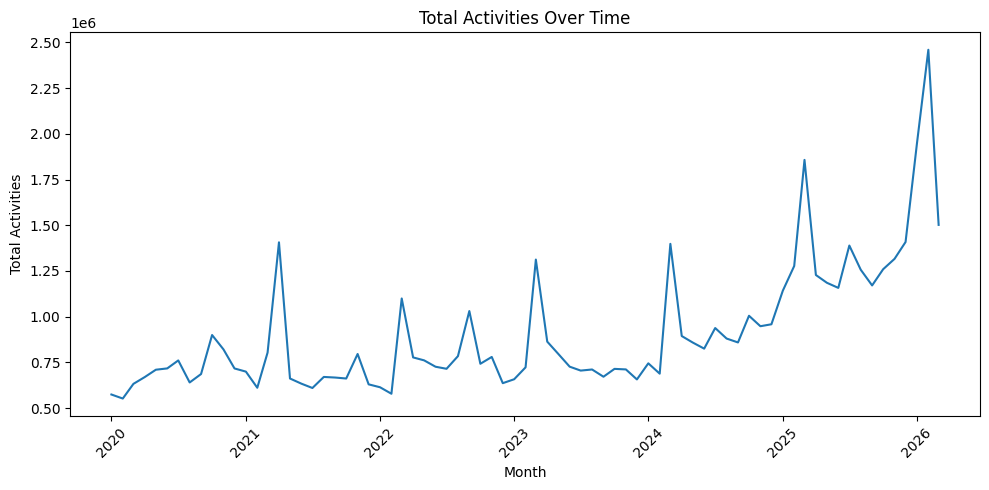

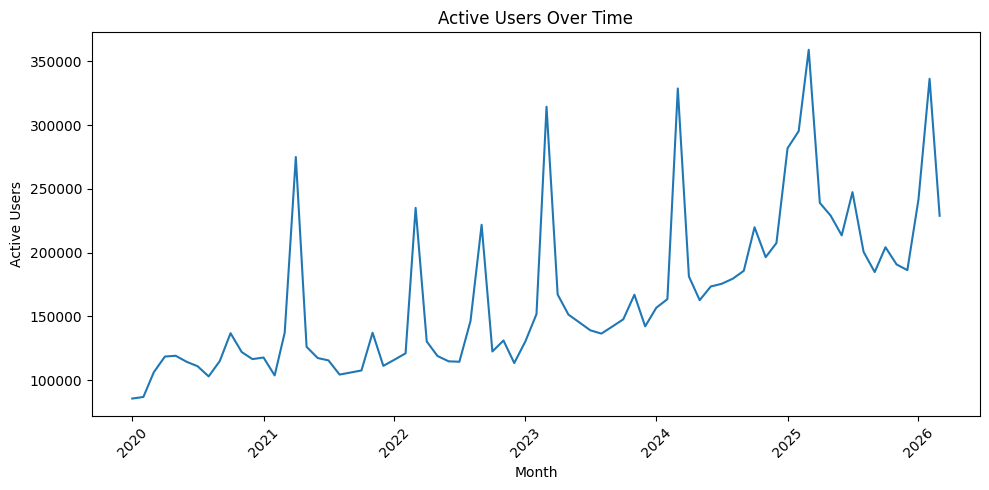

In [25]:
df = con.execute("""
SELECT
    DATE_TRUNC('month', activity_date) AS month,
    COUNT(*) AS total_activities,
    COUNT(DISTINCT dev_contact) AS active_users
FROM activity_final
GROUP BY 1
ORDER BY 1
""").fetchdf()

plt.figure(figsize=(10,5))
plt.plot(df["month"], df["total_activities"])
plt.title("Total Activities Over Time")
plt.xlabel("Month")
plt.ylabel("Total Activities")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,5))
plt.plot(df["month"], df["active_users"])
plt.title("Active Users Over Time")
plt.xlabel("Month")
plt.ylabel("Active Users")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 2. New vs Returning Users

This section distinguishes between newly active developers and returning users.

Key questions:
- Are we acquiring new developers over time?
- Is engagement driven more by new or existing users?

In [26]:
df = con.execute("""
SELECT
    DATE_TRUNC('month', first_seen_activity_date) AS cohort_month,
    COUNT(*) AS new_users
FROM developer_feature_base
GROUP BY 1
ORDER BY 1
""").fetchdf()

df.head()

,cohort_month,new_users
0,2020-01-01,85475
1,2020-02-01,71508
2,2020-03-01,82614
3,2020-04-01,88659
4,2020-05-01,85832


In [27]:
df = con.execute("""
SELECT
    DATE_TRUNC('month', a.activity_date) AS month,
    COUNT(DISTINCT CASE 
        WHEN DATE_TRUNC('month', a.activity_date) = DATE_TRUNC('month', c.first_activity_date)
        THEN a.dev_contact 
    END) AS new_users,
    COUNT(DISTINCT a.dev_contact) AS total_users
FROM activity_final a
LEFT JOIN contact_final c
    ON a.dev_contact = c.developer_id
GROUP BY 1
ORDER BY 1
""").fetchdf()
df.head()

,month,new_users,total_users
0,2020-01-01,38303,85477
1,2020-02-01,38643,86720
2,2020-03-01,50669,106107
3,2020-04-01,61003,118419
4,2020-05-01,61179,119033


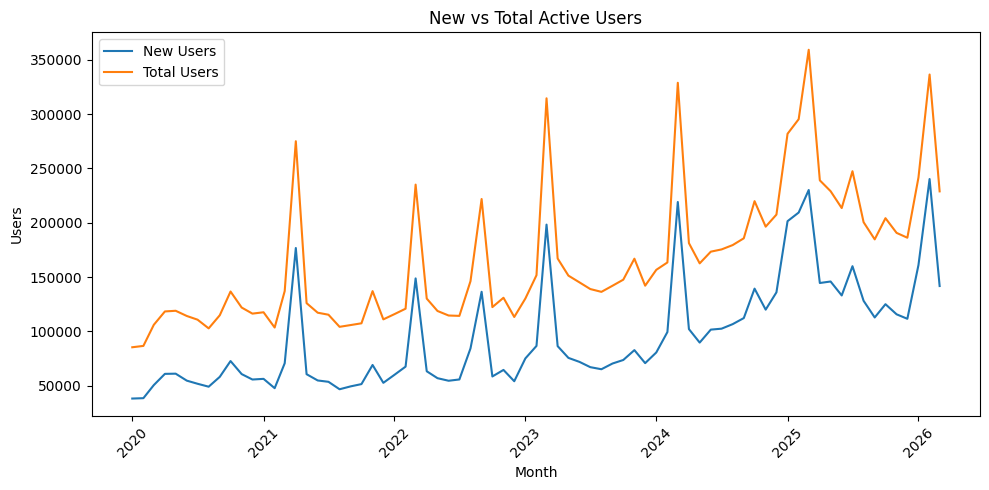

In [28]:
df = con.execute("""
SELECT
    DATE_TRUNC('month', a.activity_date) AS month,
    COUNT(DISTINCT CASE
        WHEN DATE_TRUNC('month', a.activity_date) = DATE_TRUNC('month', c.first_activity_date)
        THEN a.dev_contact
    END) AS new_users,
    COUNT(DISTINCT a.dev_contact) AS total_users
FROM activity_final a
LEFT JOIN contact_final c
    ON a.dev_contact = c.developer_id
GROUP BY 1
ORDER BY 1
""").fetchdf()

plt.figure(figsize=(10,5))
plt.plot(df["month"], df["new_users"], label="New Users")
plt.plot(df["month"], df["total_users"], label="Total Users")
plt.title("New vs Total Active Users")
plt.xlabel("Month")
plt.ylabel("Users")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 3. Activity Category Distribution

This section analyzes how engagement is distributed across activity types.

Key questions:
- Which activity categories dominate engagement?
- Are users mostly exploring, learning, building, or contributing?

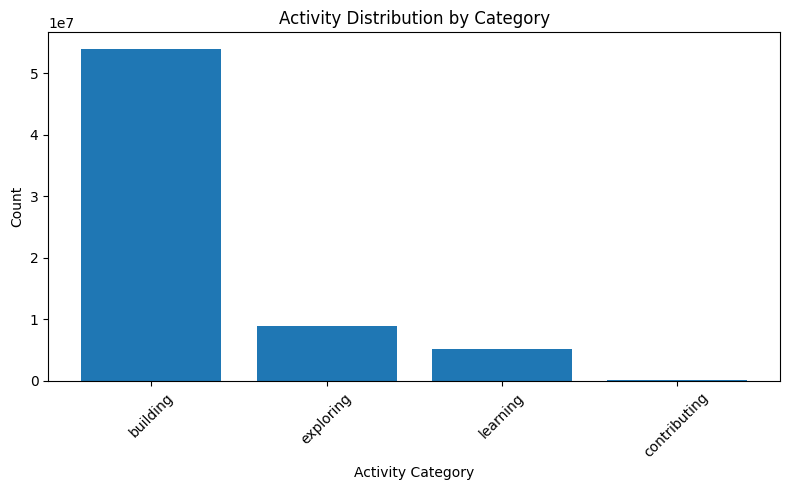

In [29]:
df = con.execute("""
SELECT
    activity_category,
    COUNT(*) AS activity_count
FROM activity_final
GROUP BY 1
ORDER BY 2 DESC
""").fetchdf()

plt.figure(figsize=(8,5))
plt.bar(df["activity_category"], df["activity_count"])
plt.title("Activity Distribution by Category")
plt.xlabel("Activity Category")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 4. Activity Categories Over Time

This section tracks how different activity categories evolve over time.

Key questions:
- Are developers progressing from learning to building?
- Are certain activity types growing or declining?

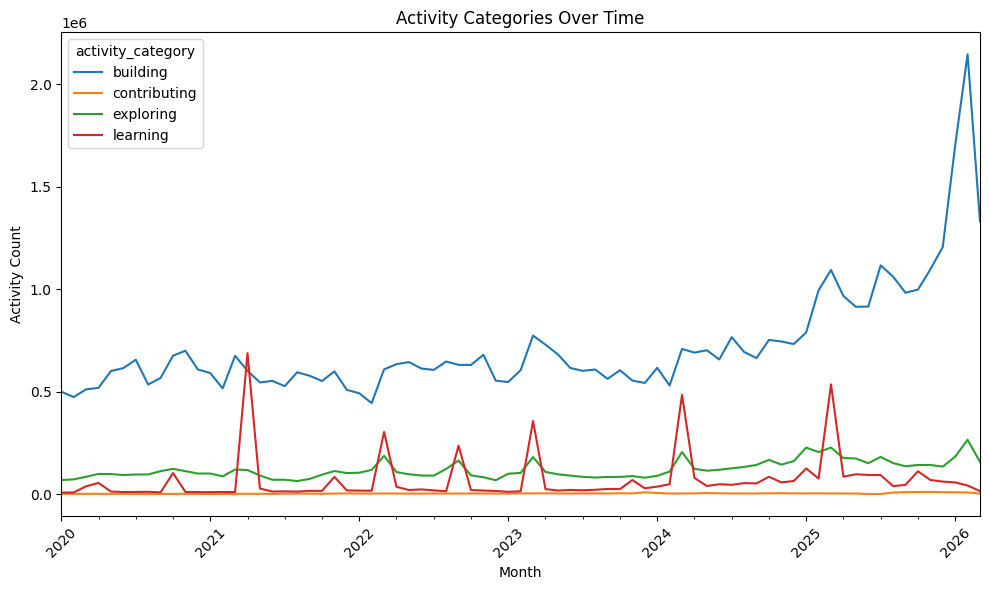

In [30]:
df = con.execute("""
SELECT
    DATE_TRUNC('month', activity_date) AS month,
    activity_category,
    COUNT(*) AS activity_count
FROM activity_final
GROUP BY 1,2
ORDER BY 1,2
""").fetchdf()

pivot_df = df.pivot(index="month", columns="activity_category", values="activity_count").fillna(0)

pivot_df.plot(figsize=(10,6))
plt.title("Activity Categories Over Time")
plt.xlabel("Month")
plt.ylabel("Activity Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 5. Engagement Depth

This section examines how deeply users engage with the platform.

Key questions:
- Do users interact with multiple activity categories?
- Are users specialists or generalists?

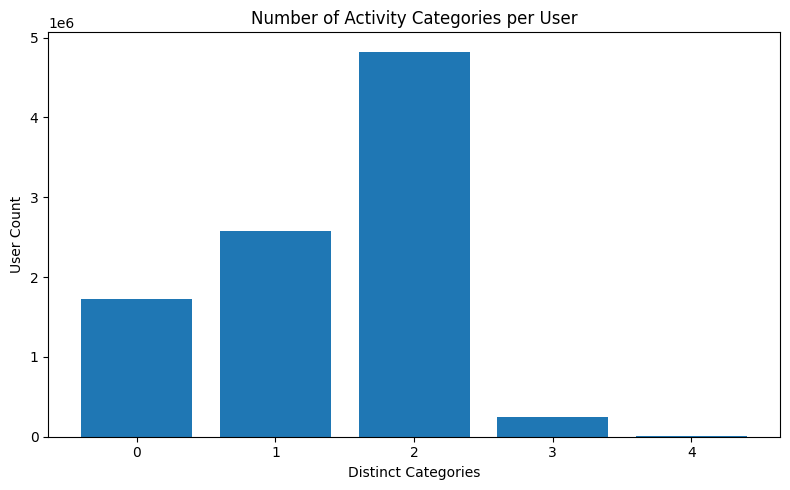

In [31]:
df = con.execute("""
SELECT
    distinct_categories_all_time,
    COUNT(*) AS user_count
FROM developer_feature_base
GROUP BY 1
ORDER BY 1
""").fetchdf()

plt.figure(figsize=(8,5))
plt.bar(df["distinct_categories_all_time"], df["user_count"])
plt.title("Number of Activity Categories per User")
plt.xlabel("Distinct Categories")
plt.ylabel("User Count")
plt.tight_layout()
plt.show()

## 6. Recency vs Engagement

This section explores how recent activity relates to overall engagement.

Key questions:
- Are highly active users more recently engaged?
- Do inactive users show lower historical engagement?

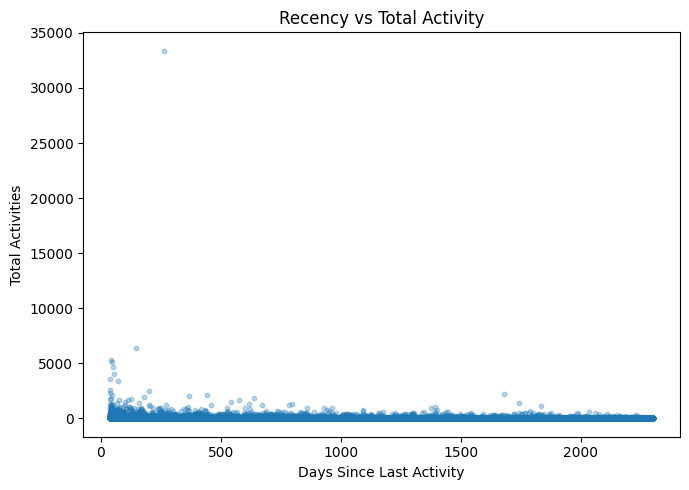

In [32]:
df = con.execute("""
SELECT
    days_since_last_activity,
    total_activities_all_time
FROM developer_feature_base
WHERE days_since_last_activity < 3650
LIMIT 100000
""").fetchdf()

plt.figure(figsize=(7,5))
plt.scatter(df["days_since_last_activity"], df["total_activities_all_time"], alpha=0.3, s=10)
plt.title("Recency vs Total Activity")
plt.xlabel("Days Since Last Activity")
plt.ylabel("Total Activities")
plt.tight_layout()
plt.show()

## 7. Engagement by Geography

This section evaluates engagement intensity across countries.

Key questions:
- Which countries have the most engaged developers?
- Are high-value users concentrated geographically?

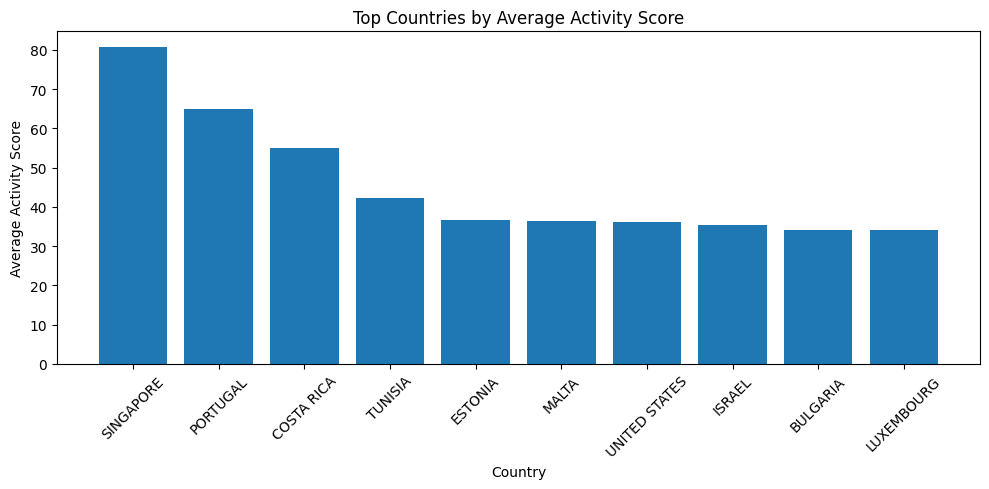

In [33]:
df = con.execute("""
SELECT
    country,
    AVG(total_activities_all_time) AS avg_activities,
    AVG(total_activity_score_all_time) AS avg_score
FROM developer_feature_base
GROUP BY 1
HAVING COUNT(*) > 1000
ORDER BY avg_score DESC
LIMIT 10
""").fetchdf()

plt.figure(figsize=(10,5))
plt.bar(df["country"], df["avg_score"])
plt.title("Top Countries by Average Activity Score")
plt.xlabel("Country")
plt.ylabel("Average Activity Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 8. Engagement Funnel

This section approximates a developer engagement funnel from exploring to contributing.

Key questions:
- Where do users drop off?
- How many users progress to deeper engagement stages?

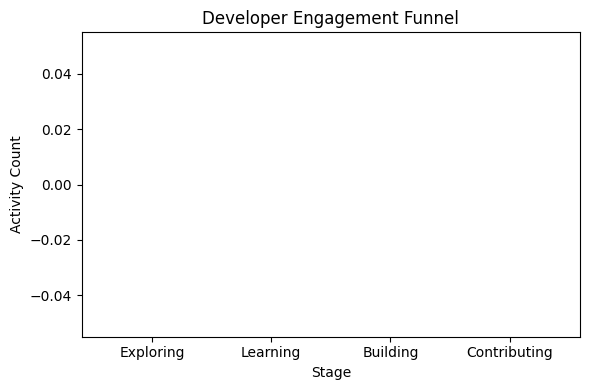

In [34]:
df = con.execute("""
SELECT
    SUM(exploring_cnt_30d) AS exploring,
    SUM(learning_cnt_30d) AS learning,
    SUM(building_cnt_30d) AS building,
    SUM(contributing_cnt_30d) AS contributing
FROM developer_feature_base
""").fetchdf()

plot_df = pd.DataFrame({
    "Stage": ["Exploring", "Learning", "Building", "Contributing"],
    "Count": [
        df.loc[0, "exploring"],
        df.loc[0, "learning"],
        df.loc[0, "building"],
        df.loc[0, "contributing"]
    ]
})

plt.figure(figsize=(6,4))
plt.bar(plot_df["Stage"], plot_df["Count"])
plt.title("Developer Engagement Funnel")
plt.xlabel("Stage")
plt.ylabel("Activity Count")
plt.tight_layout()
plt.show()

## Correlation Between Features

This analysis identifies relationships between features to:
- detect redundancy
- understand underlying behavioral dimensions
- guide feature selection for clustering

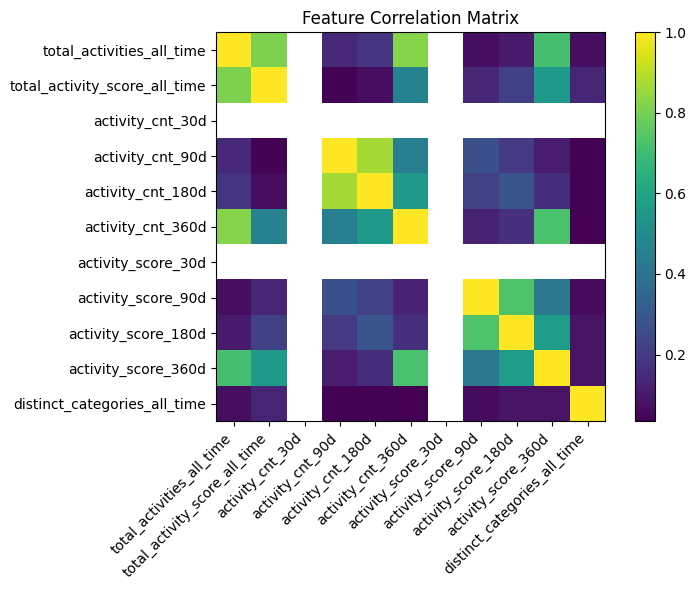

In [35]:
df = con.execute("""
SELECT
    total_activities_all_time,
    total_activity_score_all_time,
    activity_cnt_30d,
    activity_cnt_90d,
    activity_cnt_180d,
    activity_cnt_360d,
    activity_score_30d,
    activity_score_90d,
    activity_score_180d,
    activity_score_360d,
    distinct_categories_all_time
FROM developer_feature_base
LIMIT 100000
""").fetchdf()

corr = df.corr()

plt.figure(figsize=(8,6))
plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

## Feature Distribution and Skewness

We examine whether key features are skewed and require transformation before clustering.

In [37]:
import numpy as np

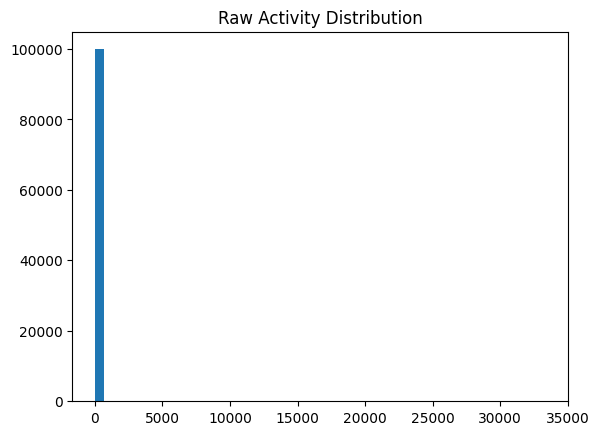

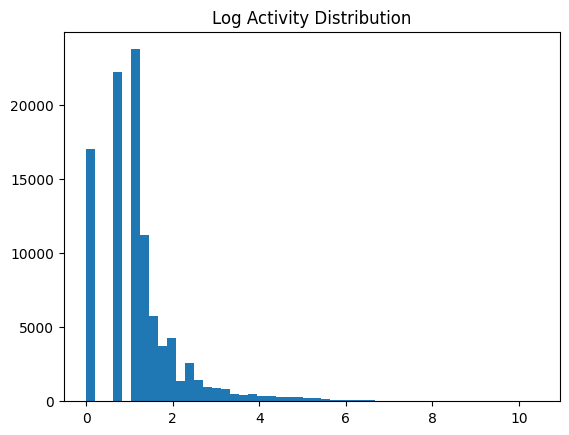

In [38]:
df = con.execute("""
SELECT
    total_activities_all_time,
    total_activity_score_all_time
FROM developer_feature_base
LIMIT 100000
""").fetchdf()

plt.hist(df["total_activities_all_time"], bins=50)
plt.title("Raw Activity Distribution")
plt.show()

plt.hist(np.log1p(df["total_activities_all_time"]), bins=50)
plt.title("Log Activity Distribution")
plt.show()

## Feature Relationships

We analyze how engagement metrics relate to each other to understand behavioral patterns.

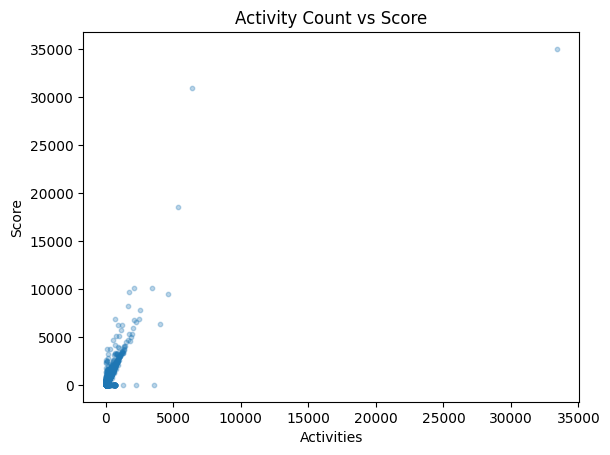

In [39]:
df = con.execute("""
SELECT
    total_activities_all_time,
    total_activity_score_all_time,
    distinct_categories_all_time
FROM developer_feature_base
LIMIT 100000
""").fetchdf()

plt.scatter(
    df["total_activities_all_time"],
    df["total_activity_score_all_time"],
    alpha=0.3,
    s=10
)
plt.title("Activity Count vs Score")
plt.xlabel("Activities")
plt.ylabel("Score")
plt.show()

## Identifying Segmentation Dimensions

We explore key behavioral dimensions that can define user segments:
- Activity volume (how much)
- Activity recency (how recent)
- Activity diversity (how broad)

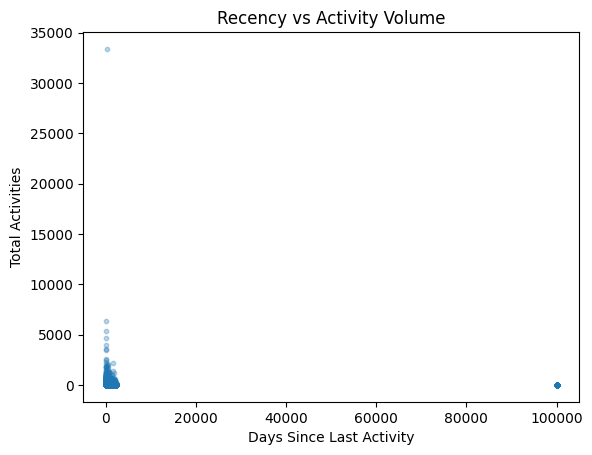

In [40]:
df = con.execute("""
SELECT
    total_activities_all_time,
    days_since_last_activity,
    distinct_categories_all_time
FROM developer_feature_base
LIMIT 100000
""").fetchdf()

plt.scatter(
    df["days_since_last_activity"],
    df["total_activities_all_time"],
    alpha=0.3,
    s=10
)
plt.title("Recency vs Activity Volume")
plt.xlabel("Days Since Last Activity")
plt.ylabel("Total Activities")
plt.show()

### Example segmentation looks like

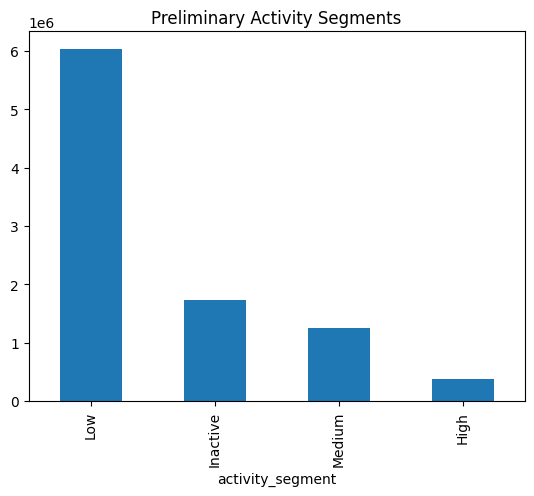

In [41]:
df = con.execute("""
SELECT
    total_activities_all_time,
    CASE
        WHEN total_activities_all_time = 0 THEN 'Inactive'
        WHEN total_activities_all_time < 5 THEN 'Low'
        WHEN total_activities_all_time < 20 THEN 'Medium'
        ELSE 'High'
    END AS activity_segment
FROM developer_feature_base
""").fetchdf()

df["activity_segment"].value_counts().plot(kind="bar")
plt.title("Preliminary Activity Segments")
plt.show()

## Key Insights from EDA

The exploratory analysis reveals several important patterns in developer behavior:

- Engagement is highly skewed, with a small group of users driving the majority of activity.
- Activity volume and activity score are strongly correlated, indicating that higher engagement is associated with deeper interaction.
- Recency is a key differentiator, separating active users from dormant ones.
- Users vary in the breadth of their engagement, with some interacting across multiple categories and others focusing narrowly.
- Activity categories suggest a natural progression from exploring to contributing, though not all users follow this path.

Overall, developer behavior can be summarized along three main dimensions:
- Volume (how much they engage)
- Recency (how recently they engage)
- Diversity (how broadly they engage)

These dimensions will guide the feature selection and clustering approach.


Your clusters will likely look like:

* Inactive users → low volume, high recency
* Casual users → low volume, recent
* Power users → high volume, recent
* Specialists → high volume, low diversity
* Explorers → moderate volume, high diversity

In [42]:
con.close()